In [3]:
import pandas as pd


file_path = r"C:\Users\sreea\Downloads\WA_Fn-UseC_-HR-Employee-Attrition.csv" 
df = pd.read_csv(file_path)


In [4]:
df.isnull().sum()


Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [5]:
df.duplicated().sum()


0

In [6]:
df.dtypes


Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWorkingYears   

In [7]:
df.drop(['EmployeeNumber', 'Over18', 'StandardHours', 'EmployeeCount'], axis=1, inplace=True)


In [8]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Attrition'] = le.fit_transform(df['Attrition'])  # Yes=1, No=0


In [9]:
df['Attrition'].value_counts(normalize=True)


Attrition
0    0.838776
1    0.161224
Name: proportion, dtype: float64

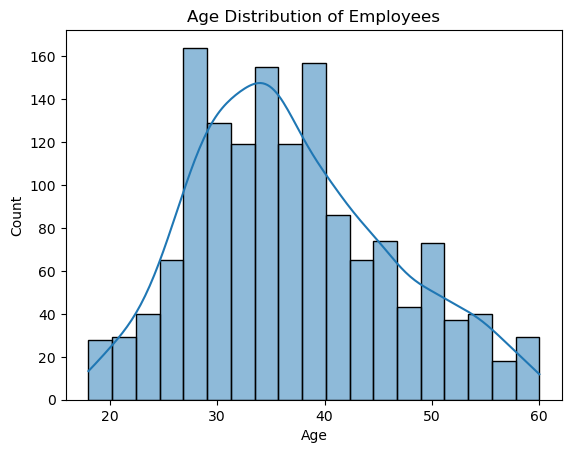

In [12]:
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=df, x='Age', kde=True)
plt.title("Age Distribution of Employees")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()



<Axes: xlabel='Gender', ylabel='count'>

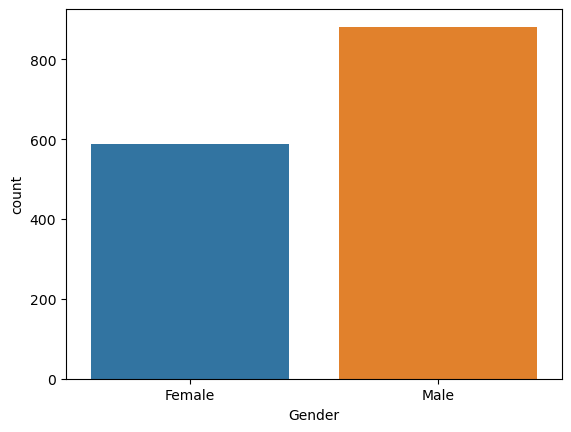

In [13]:
sns.countplot(data=df, x='Gender')


<Axes: xlabel='Department', ylabel='count'>

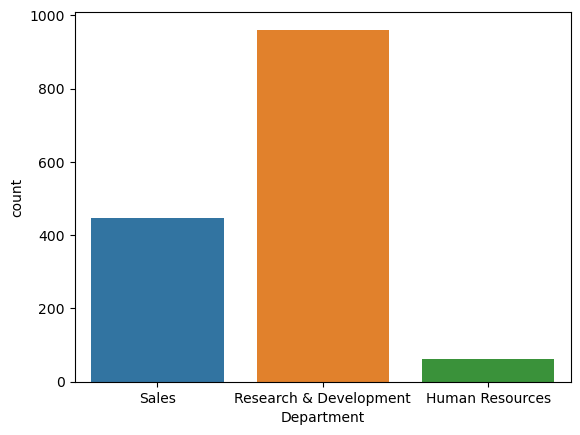

In [14]:
sns.countplot(data=df, x='Department')


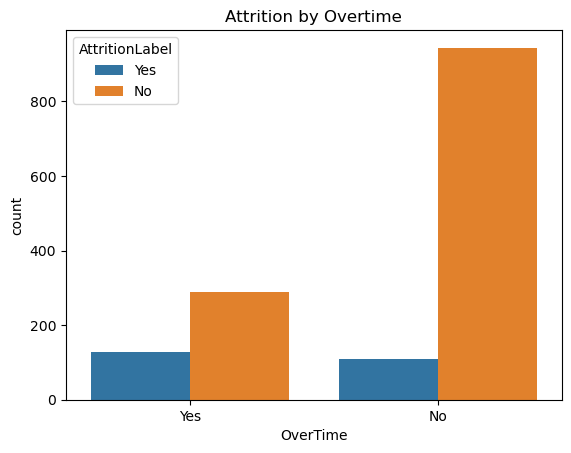

In [16]:
df['AttritionLabel'] = df['Attrition'].map({1: 'Yes', 0: 'No'})
sns.countplot(data=df, x='OverTime', hue='AttritionLabel')
plt.title('Attrition by Overtime')
plt.show()



In [17]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Attrition'] = le.fit_transform(df['Attrition'])  # Yes → 1, No → 0


In [18]:
df_encoded = pd.get_dummies(df, drop_first=True)


In [21]:
columns_to_drop = ['EmployeeNumber', 'Over18', 'StandardHours', 'EmployeeCount']
df_encoded.drop(columns=[col for col in columns_to_drop if col in df_encoded.columns], inplace=True)



In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_encoded.drop('Attrition', axis=1))
X = pd.DataFrame(scaled_features, columns=df_encoded.columns[:-1])
y = df_encoded['Attrition']


In [23]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop('Attrition', axis=1)
y = df_encoded['Attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [24]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [25]:
y_pred = model.predict(X_test)


In [26]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       380
           1       1.00      1.00      1.00        61

    accuracy                           1.00       441
   macro avg       1.00      1.00      1.00       441
weighted avg       1.00      1.00      1.00       441

[[380   0]
 [  0  61]]


In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Logistic Regression:\n", classification_report(y_test, y_pred_lr))


Logistic Regression:
               precision    recall  f1-score   support

           0       0.96      0.99      0.98       380
           1       0.90      0.77      0.83        61

    accuracy                           0.96       441
   macro avg       0.93      0.88      0.90       441
weighted avg       0.96      0.96      0.96       441



In [28]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

print("K-Nearest Neighbors:\n", classification_report(y_test, y_pred_knn))


K-Nearest Neighbors:
               precision    recall  f1-score   support

           0       0.87      0.96      0.91       380
           1       0.29      0.11      0.16        61

    accuracy                           0.84       441
   macro avg       0.58      0.54      0.54       441
weighted avg       0.79      0.84      0.81       441

